NLP_Training

In [2]:
from google.colab import files
import io

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file: {filename}')
  # To read the content of the file:
  # content = uploaded[filename].decode('utf-8')
  # print(f'File content (first 100 chars):\n{content[:100]}')
  # You can then process the content further, e.g., save it to a variable or to disk


Saving AmazonFood_Reviews.csv to AmazonFood_Reviews.csv
Uploaded file: AmazonFood_Reviews.csv


In [3]:
import pandas as pd

# Assuming the uploaded file is a CSV, you can read it directly into a pandas DataFrame
# The filename 'AmazonFood_Reviews.csv' was inferred from the upload output.
file_path = 'AmazonFood_Reviews.csv'
df = pd.read_csv(file_path)

print(f'Successfully loaded {len(df)} rows and {len(df.columns)} columns.')
print('First 5 rows of the DataFrame:')
print(df.head())

Successfully loaded 568454 rows and 10 columns.
First 5 rows of the DataFrame:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0

## Data Preprocessing for LSTM

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Assuming 'Text' is the review content and 'Score' is the sentiment/rating
texts = df['Text'].values
# Adjust scores to be 0-indexed if using categorical crossentropy (e.g., 1-5 becomes 0-4)
# Or keep as 1-5 and use SparseCategoricalCrossentropy
# For simplicity, let's use 0-indexed for now.
labels = df['Score'].values - 1 # Scores are 1-5, convert to 0-4

# Tokenization
max_words = 10000  # Consider the top 10,000 words
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(texts)

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

sequences = tokenizer.texts_to_sequences(texts)

# Padding sequences
maxlen = 100  # Max length of a review sequence
padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post')

# Convert labels to one-hot encoding for multi-class classification
num_classes = len(np.unique(labels)) # Number of unique scores (5 in this case)
labels_one_hot = to_categorical(labels, num_classes=num_classes)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_one_hot, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Found 133040 unique tokens.
X_train shape: (454763, 100)
y_train shape: (454763, 5)
X_test shape: (113691, 100)
y_test shape: (113691, 5)


## Build and Train LSTM Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Model Parameters
embedding_dim = 128

# Build the LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=maxlen),
    LSTM(128, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
# Using a small subset of data for demonstration due to potential memory/time constraints with full dataset
# For full training, remove the [:10000] slicing
history = model.fit(
    X_train,
    y_train,
    epochs= 15, # You might want to increase epochs for better performance
    batch_size=64,
    validation_split=0.1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2240s 350ms/step - accuracy: 0.6944 - loss: 0.8545 - val_accuracy: 0.7429 - val_loss: 0.6835
Epoch 2/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2257s 352ms/step - accuracy: 0.7577 - loss: 0.6490 - val_accuracy: 0.7586 - val_loss: 0.6358
Epoch 3/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2282s 349ms/step - accuracy: 0.7867 - loss: 0.5774 - val_accuracy: 0.7790 - val_loss: 0.6067
Epoch 4/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2191s 343ms/step - accuracy: 0.8111 - loss: 0.5191 - val_accuracy: 0.7838 - val_loss: 0.6044
Epoch 5/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2184s 342ms/step - accuracy: 0.8327 - loss: 0.4674 - val_accuracy: 0.7924 - val_loss: 0.5903
Epoch 6/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2177s 340ms/step - accuracy: 0.8508 - loss: 0.4205 - val_accuracy: 0.7963 - val_loss: 0.6012
Epoch 7/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2179s 341ms/step - accuracy: 0.8668 - loss: 0.3807 - val_accuracy: 0.7986 - val_loss: 0.6306
Epoch 8/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 2208s 345ms/s

## Evaluate and Summarize Training Results

In [6]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Display training history
print("\nTraining History:")
for epoch in range(len(history.history['loss'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Loss: {history.history['loss'][epoch]:.4f}, Accuracy: {history.history['accuracy'][epoch]:.4f}")
    if 'val_loss' in history.history:
        print(f"  Val Loss: {history.history['val_loss'][epoch]:.4f}, Val Accuracy: {history.history['val_accuracy'][epoch]:.4f}")



Test Loss: 0.8221
Test Accuracy: 0.8051

Training History:
Epoch 1:
  Loss: 0.8545, Accuracy: 0.6944
  Val Loss: 0.6835, Val Accuracy: 0.7429
Epoch 2:
  Loss: 0.6490, Accuracy: 0.7577
  Val Loss: 0.6358, Val Accuracy: 0.7586
Epoch 3:
  Loss: 0.5774, Accuracy: 0.7867
  Val Loss: 0.6067, Val Accuracy: 0.7790
Epoch 4:
  Loss: 0.5191, Accuracy: 0.8111
  Val Loss: 0.6044, Val Accuracy: 0.7838
Epoch 5:
  Loss: 0.4674, Accuracy: 0.8327
  Val Loss: 0.5903, Val Accuracy: 0.7924
Epoch 6:
  Loss: 0.4205, Accuracy: 0.8508
  Val Loss: 0.6012, Val Accuracy: 0.7963
Epoch 7:
  Loss: 0.3807, Accuracy: 0.8668
  Val Loss: 0.6306, Val Accuracy: 0.7986
Epoch 8:
  Loss: 0.3450, Accuracy: 0.8809
  Val Loss: 0.6415, Val Accuracy: 0.7997
Epoch 9:
  Loss: 0.3143, Accuracy: 0.8929
  Val Loss: 0.6512, Val Accuracy: 0.8018
Epoch 10:
  Loss: 0.2877, Accuracy: 0.9025
  Val Loss: 0.6749, Val Accuracy: 0.8012
Epoch 11:
  Loss: 0.2633, Accuracy: 0.9113
  Val Loss: 0.7175, Val Accuracy: 0.8024
Epoch 12:
  Loss: 0.2429,

## Visualize Training History

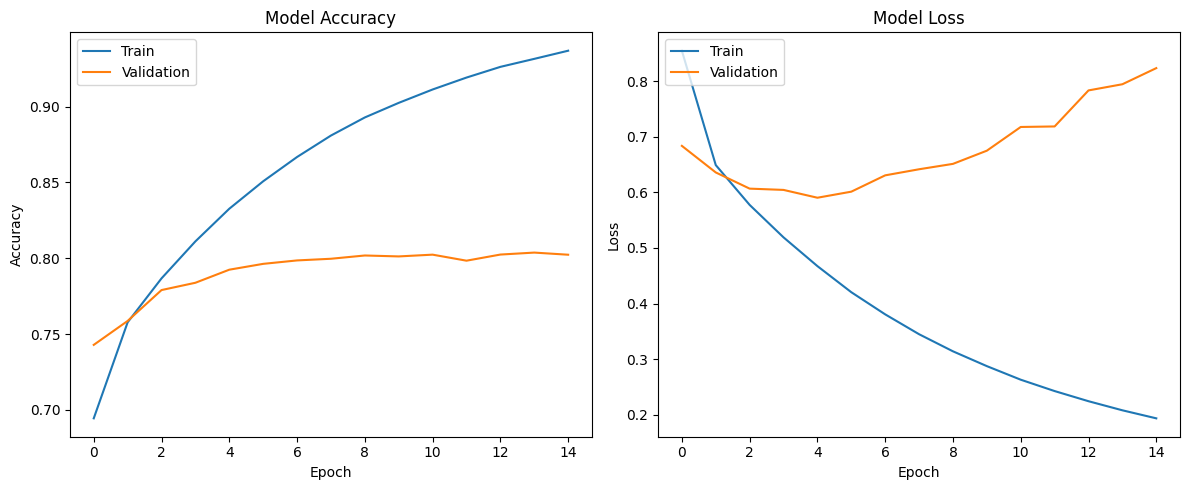

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


After running the cell above, a button will appear. Click on it to select your `.txt` file from your local system. The file will be uploaded to the Colab environment.